<a href="https://colab.research.google.com/github/RGarancs/applied-ai-academy-labs/blob/main/solutions/churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer churn (synthetic)

**Applied AI Academy — problem set with worked answers**

**Used in:** Lesson 2 — A prediction is not a decision — and never a cause  
**Rows:** 400  ·  **Source file:** `customer_churn_synthetic.csv`



---
### How to use this notebook
Run the cells in order. Each problem is stated first, then solved, then the
answer is spelled out. For teaching, hide the solution cells and let the room
attempt the task before revealing them.

> The data loads straight from `appliedai.center` — nothing to upload.


## Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, os, urllib.request
import matplotlib, matplotlib.pyplot as plt
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Applied AI Academy chart style — calm, legible when projected
INK, ACCENT, CORE, BUILDER, DANGER = "#26214a", "#544d94", "#5b8a6e", "#a8845c", "#b05a5a"
matplotlib.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c4d8", "axes.labelcolor": INK, "axes.titlesize": 13,
    "axes.titleweight": "600", "axes.titlecolor": INK, "axes.titlepad": 14,
    "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 10, "grid.color": "#e6e2ef", "axes.grid": True,
    "axes.axisbelow": True, "grid.linewidth": .8, "figure.facecolor": "white",
})

URL   = "https://appliedai.center/assets/datasets/customer_churn_synthetic.csv"
LOCAL = "customer_churn_synthetic.csv"
if not os.path.exists(LOCAL):
    print("Downloading", URL)
    urllib.request.urlretrieve(URL, LOCAL)

df = pd.read_csv(LOCAL, low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (400, 9)


,customer_id,tenure_months,monthly_spend,support_tickets_90d,late_payments_12m,product_count,nps,contract_type,churned
0,C0001,15,108.76,0,2,1,10,monthly,0
1,C0002,5,88.77,0,0,1,8,monthly,0
2,C0003,70,56.34,0,3,1,2,monthly,0
3,C0004,20,100.87,0,3,2,1,monthly,0
4,C0005,46,108.47,2,2,2,8,monthly,0


## What is in the file

In [2]:
print("Columns and types:")
print(df.dtypes.to_string())
miss = df.isna().sum()
miss = miss[miss > 0]
print("\nMissing values:" if len(miss) else "\nNo missing values.")
if len(miss): print(miss.to_string())

Columns and types:
customer_id                str
tenure_months            int64
monthly_spend          float64
support_tickets_90d      int64
late_payments_12m        int64
product_count            int64
nps                      int64
contract_type              str
churned                  int64

No missing values.


---
## Problem 1 · Easy — describe

Baseline: how many customers churn, and does that differ by contract type?

*Try it yourself first. The worked solution is below.*

In [3]:
base = df["churned"].mean()
print(f"Overall churn rate: {base:.1%}  ({df['churned'].sum()} of {len(df)})")

by_contract = (df.groupby("contract_type")["churned"]
                 .agg(customers="size", churned="sum", rate="mean")
                 .sort_values("rate", ascending=False))
by_contract["rate"] = (by_contract["rate"] * 100).round(1)
print("\nChurn by contract type (%):")
print(by_contract)

Overall churn rate: 6.0%  (24 of 400)

Churn by contract type (%):
               customers  churned  rate
contract_type                          
monthly              209       18   8.6
annual               191        6   3.1


---
## Problem 2 · Intermediate — build

Which behaviours separate churners from stayers?

*Try it yourself first. The worked solution is below.*

In [4]:
num = ["tenure_months","monthly_spend","support_tickets_90d",
       "late_payments_12m","product_count","nps"]
comp = df.groupby("churned")[num].mean().T
comp.columns = ["stayed","churned"]
comp["gap"] = comp["churned"] - comp["stayed"]
comp["gap_%_of_stayed"] = (comp["gap"] / comp["stayed"] * 100).round(1)
print(comp.round(2).sort_values("gap_%_of_stayed", key=abs, ascending=False))

                     stayed  churned    gap  gap_%_of_stayed
late_payments_12m      1.03     1.67   0.63             61.5
tenure_months         37.97    26.50 -11.47            -30.2
nps                    5.39     3.92  -1.47            -27.3
monthly_spend         83.76    70.73 -13.03            -15.6
product_count          2.19     2.04  -0.15             -6.9
support_tickets_90d    1.19     1.17  -0.02             -2.1


---
## Problem 3 · Advanced — judge

Threshold economics: at what score do retention offers stop paying?

*Try it yourself first. The worked solution is below.*

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X = pd.get_dummies(df[["tenure_months","monthly_spend","support_tickets_90d",
                       "late_payments_12m","product_count","nps","contract_type"]],
                   drop_first=True)
y = df["churned"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.3, random_state=42, stratify=y)
m = LogisticRegression(max_iter=2000).fit(Xtr, ytr)
p = m.predict_proba(Xte)[:, 1]
print(f"AUC: {roc_auc_score(yte, p):.3f}")

# The business question is NOT accuracy — it is whether an offer pays.
OFFER_COST, SAVED_VALUE, SAVE_RATE = 25, 300, 0.30   # €, €, share persuadable
print("\nthreshold  targeted  true_churners  net_€")
for t in [.2,.3,.4,.5,.6,.7]:
    tgt = p >= t
    n, hits = tgt.sum(), yte[tgt].sum()
    net = hits * SAVE_RATE * SAVED_VALUE - n * OFFER_COST
    print(f"   {t:.1f}      {n:5d}      {hits:5d}       {net:8.0f}")
print("\nThe best threshold is an economics question, not a modelling one.")

AUC: 0.675

threshold  targeted  true_churners  net_€
   0.2          8          2            -20
   0.3          2          1             40
   0.4          2          1             40
   0.5          1          1             65
   0.6          0          0              0
   0.7          0          0              0

The best threshold is an economics question, not a modelling one.


---
## Visual summary

The same answers, as pictures. These are what to project — a room reads a chart
far faster than it reads a table, and the shape of a result is usually the
argument you are actually making.

findfont: Failed to find font weight 600, now using 700.


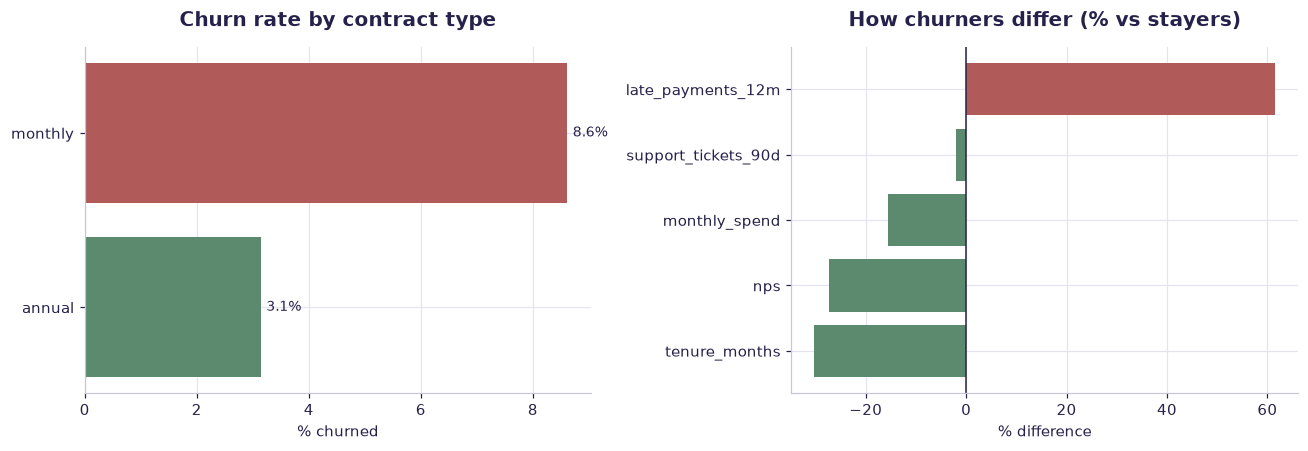

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
r = df.groupby("contract_type")["churned"].mean().mul(100).sort_values()
ax[0].barh(r.index, r.values, color=[CORE if v < r.mean() else DANGER for v in r])
ax[0].set_title("Churn rate by contract type"); ax[0].set_xlabel("% churned")
for i, v in enumerate(r.values): ax[0].text(v + .1, i, f"{v:.1f}%", va="center", fontsize=9)

num = ["tenure_months","monthly_spend","support_tickets_90d","late_payments_12m","nps"]
g = df.groupby("churned")[num].mean()
rel = ((g.loc[1] - g.loc[0]) / g.loc[0] * 100).sort_values()
ax[1].barh(rel.index, rel.values, color=[DANGER if v > 0 else CORE for v in rel])
ax[1].axvline(0, color=INK, lw=1)
ax[1].set_title("How churners differ (% vs stayers)"); ax[1].set_xlabel("% difference")
plt.tight_layout(); plt.show()

---
## Verified answer key

These are the numbers the academy ships for this dataset. They were computed
from this exact file — if your run disagrees, reconcile before teaching it.

1. Churn rate 6.0% (24/400) — beware the accuracy trap
2. Monthly contracts churn 8.6% vs annual 3.1%
3. Churned: lower tenure (26.5 vs 38.0 mo), more late payments (1.67 vs 1.03), lower NPS (3.9 vs 5.4)
4. Support tickets: almost NO signal (1.17 vs 1.19) — the trap feature


---
## Teaching notes

* **Run the Easy problem live.** It sets the shared vocabulary and gets everyone
  looking at the same rows.
* **Let them fail on the Intermediate one.** The productive mistake is usually
  reaching for a model before checking the data.
* **Argue about the Advanced one.** It has no single right answer; it has a
  defensible one, and defending it is the skill being taught.
* **Always close on limitations.** Every dataset here has a real caveat —
  scrape bias, a tiny sample, a hindsight label. Naming it is the lesson.
* **Deliverable for learners:** A one-page model card: purpose, data, top drivers, chosen threshold + economic reasoning, limitations, owner.

---
*Applied AI Academy · appliedai.center*
